In [3]:
pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 10.4 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.2
    Uninstalling pip-25.2:
      Successfully uninstalled pip-25.2
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install opencv-python 


   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   - -------------------------------------- 1.8/39.0 MB 13.1 MB/s eta 0:00:03
   -------- ------------------------------- 8.1/39.0 MB 23.8 MB/s eta 0:00:02
   --------------- ------------------------ 14.7/39.0 MB 26.8 MB/s eta 0:00:01
   ---------------------- ----------------- 21.5/39.0 MB 28.5 MB/s eta 0:00:01
   ----------------------------- ---------- 28.8/39.0 MB 30.1 MB/s eta 0:00:01
   ------------------------------------- -- 37.0/39.0 MB 31.7 MB/s eta 0:00:01
   ---------------------------------------- 39.0/39.0 MB 29.6 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


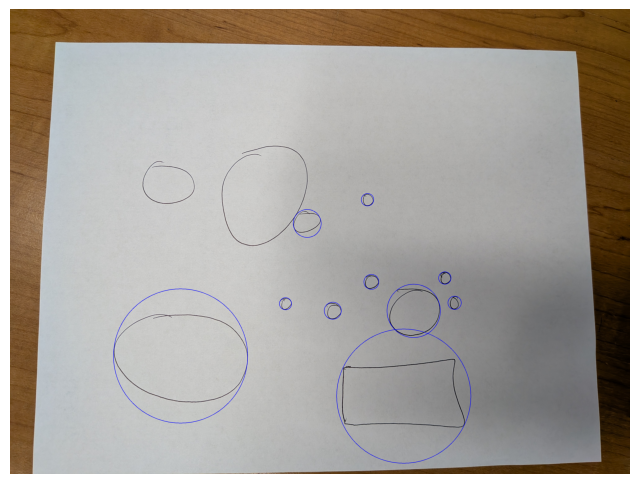

True

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("handdrawnNL2.jpg")
gray = cv2.cvtColor(img, 10)
blur = cv2.GaussianBlur(gray, (5,5), 0)

_, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY_INV)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
circlecountours=[]
radii=[]
for cnt in contours:
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    if perimeter == 0:
        continue
    circularity = 4 * np.pi * (area / (perimeter**2))
    if circularity > 0.2:  # 1.0 is perfect circle
        
        (x, y), r = cv2.minEnclosingCircle(cnt)
        if(r > 20):
            cv2.circle(img, (int(x), int(y)), int(r), (255, 0, 0), 2)
            circlecountours.append((x,y))
            radii.append(r)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,8))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

# Save the image
cv2.imwrite("handdrawn_circles_detectedNL2.jpg", img_rgb)

In [11]:
circlecountours

[(2540.0, 2497.0),
 (1100.8966064453125, 2238.442626953125),
 (2082.806396484375, 1946.1766357421875),
 (1777.9283447265625, 1901.7724609375),
 (2868.207763671875, 1895.2528076171875),
 (2604.231201171875, 1947.47119140625),
 (2331.700927734375, 1760.807861328125),
 (2805.354248046875, 1735.3734130859375),
 (1917.098876953125, 1383.529052734375),
 (2306.800048828125, 1230.199951171875)]

In [13]:
radii

[433.51824951171875,
 433.1826171875,
 55.32596969604492,
 39.49586486816406,
 43.94921112060547,
 172.61708068847656,
 48.57744598388672,
 40.977874755859375,
 90.5147933959961,
 40.55720520019531]